## Introduction to the automatic differentiation framework (reverse accumulation mode)

### Basic elements (cost function, manual gradient descent)

We import the libraries

In [2]:
import gpt as g
import numpy as np
import matplotlib.pyplot as plt

and setup a basic RNG, grid, and module shortcut

In [3]:
rng = g.random("test3")
grid = g.grid([4, 4, 4, 4], g.double)
rad = g.ad.reverse

GPT :       2.057125 s : Initializing gpt.random(test3,vectorized_ranlux24_389_64) took 0.000457048 s


With this, we can now define a minimal model and training target

In [4]:
V_in = rad.node(g.complex(grid))
V_out = rad.node(g.complex(grid))

rng.cnormal(V_in.value)
rng.cnormal(V_out.value)

c = g.norm2(V_in - V_out)

print(c)

(inner_product):
 (-):
  leaf(lattice;ot_complex_additive_group;5478826304)
  leaf(lattice;ot_complex_additive_group;5478826304)
 (-):
  leaf(lattice;ot_complex_additive_group;5478826304)
  leaf(lattice;ot_complex_additive_group;5478826304)


we first verify that both fields are different

In [5]:
print(g.norm2(V_in.value - V_out.value))

1004.2630610592337


and now perform a simple gradient descent to learn V_out to minimize the cost c

In [6]:
for i in range(100):
    cv = c()
    if i % 10 == 0:
        print(i, cv)
    V_out.value -= 0.1 * V_out.gradient

0 (1004.2630610592337+9.577911277530653e-16j)
10 (11.578364793774895-2.4362666752926576e-17j)
20 (0.13348945758925906-2.316043041397405e-19j)
30 (0.0015390286629296075-1.823603900471013e-21j)
40 (1.7743792416978686e-05-4.403674402676033e-23j)
50 (2.045719985081435e-07-2.593803886085082e-25j)
60 (2.358554563192993e-09-9.751689944166233e-28j)
70 (2.7192282754885348e-11+4.762246973486318e-29j)
80 (3.1350567544807327e-13+9.079255055016765e-31j)
90 (3.614474349683836e-15-5.89816045468591e-34j)


we now verify that the fields are identical

In [7]:
print(g.norm2(V_out.value - V_in.value))

4.167205396494112e-17


## Restricting the optimization manifold

Next, we repeat the above process, however, we reduce the optimization manifold from $\mathbb{C}$ to U(1)

In [8]:
V_in = rad.node(g.complex(grid))
V_out = rad.node(g.u1(grid))

rng.cnormal(V_in.value)
rng.element(V_out.value)

c = g.norm2(V_in - g.astype(V_out, V_in.otype))

In [9]:
for i in range(100):
    cv = c()
    if i % 10 == 0:
        print(i, cv)
    V_out.value @= g.group.compose(-0.1 * V_out.gradient, V_out.value)

0 (745.9602160794481+1.2776741710128538e-15j)
10 (222.7907420855028+2.0274185740366887e-16j)
20 (145.3336482558149-3.772609136550914e-16j)
30 (129.30200020352888+4.232499640181824e-17j)
40 (124.15159488392364+5.629456566717641e-17j)
50 (122.39315603294148+1.4147036902053106e-17j)
60 (121.68721754629209+8.222183006528778e-17j)
70 (121.4278852475961-4.6512295223488445e-17j)
80 (121.34302014333409+1.0526047949084856e-16j)
90 (121.31133709487676+1.3629311212884977e-16j)


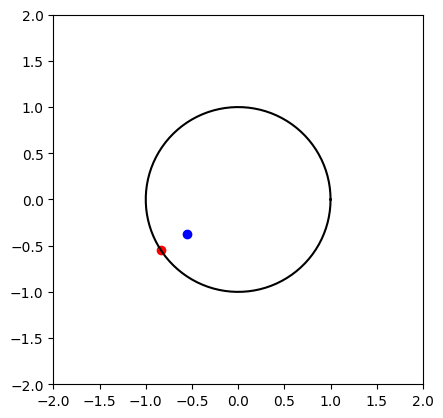

In [10]:
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.gca().set_aspect('equal')
plt.plot(np.cos(np.linspace(0,np.pi*2,100)), np.sin(np.linspace(0,np.pi*2,100)),color="black")
plt.scatter(V_out.value[0,0,0,0].real, V_out.value[0,0,0,0].imag,color="red")
plt.scatter(V_in.value[0,0,0,0].real, V_in.value[0,0,0,0].imag,color="blue")
plt.show()


## Using functionals and optimizers

For realistic problems, we may wish to use existing optimizers in GPT such as Adam.
Here is how.

In [11]:
V_in = rad.node(g.complex(grid))
V_out = rad.node(g.u1(grid))

c = g.norm2(V_in - g.astype(V_out, V_in.otype))

cf = c.functional(V_in, V_out)

v_in = rng.cnormal(g.complex(grid))
v_out = rng.element(g.u1(grid))

# print value of functional for values of fields v_in and v_out
print(cf([v_in, v_out]))

789.6450125039


GPT :       4.884963 s : adam: iteration 0: f(x) = 6.857093962869221e+02, |df|/sqrt(dof) = 1.435254e+00, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       4.992336 s : adam: iteration 40: f(x) = 1.338429956015996e+02, |df|/sqrt(dof) = 8.332229e-02, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       5.080325 s : adam: iteration 80: f(x) = 1.298916802792411e+02, |df|/sqrt(dof) = 1.876294e-02, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       5.167436 s : adam: iteration 120: f(x) = 1.296135697663980e+02, |df|/sqrt(dof) = 6.964285e-03, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       5.253291 s : adam: iteration 160: f(x) = 1.295648778189072e+02, |df|/sqrt(dof) = 3.174206e-03, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       5.343259 s : adam: iteration 200: f(x) = 1.295549087364452e+02, |df|/sqrt(dof) = 1.418829e-03, alpha = 10000000.0, beta1 = 0, beta2 = 0.99999999
GPT :       5.382669 s : adam: converged in 219 iterations: f(

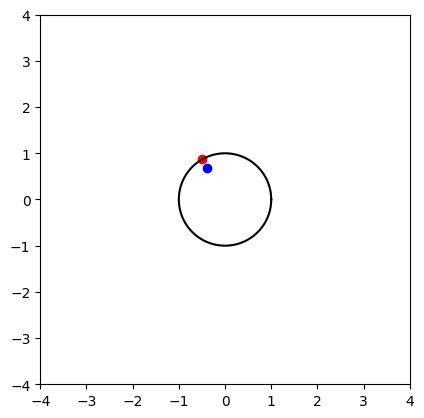

In [12]:
# print(cf.gradient([v_in, v_out], [v_out])

# this is Adam, for now tuned to mimick a simple gradient descent
opt = g.algorithms.optimize.adam(
    maxiter=400, eps=1e-3, eps_regulator=1e8, alpha=0.1*1e8, beta1=0, beta2=1 - 1e-8, 
    log_functional_every=40
)

# now create the optimizer for the functional cf
# and run it by only allowing changes to v_out
opt(cf)([v_in, v_out], [v_out])

# and plot result
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.gca().set_aspect('equal')
plt.plot(np.cos(np.linspace(0,np.pi*2,100)), np.sin(np.linspace(0,np.pi*2,100)),color="black")
plt.scatter(v_out[0,0,0,0].real, v_out[0,0,0,0].imag,color="red")
plt.scatter(v_in[0,0,0,0].real, v_in[0,0,0,0].imag,color="blue")
plt.show()

### Let's learn a Wilson Dirac operator



In [13]:
U = g.qcd.gauge.random(grid, rng)

paths = (
    [g.path()] +
    [g.path().f(mu) for mu in range(4)] +
    [g.path().b(mu) for mu in range(4)]
)

dir_disps = [p.path[0] if len(p.path) > 0 else None for p in paths]

pt = g.parallel_transport(U, paths)

pt_U = pt(U)

# test output of parallel transport
print(g.norm2(pt_U[1] - U[0]))
print(g.norm2(pt_U[4] - U[3]))
print(g.norm2(pt_U[5] - g.cshift(g.adj(U[0]),0,-1)))

node_U = [rad.node(u, with_gradient=False) for u in pt_U]

0.0
0.0
0.0


In [14]:
def layer_pt(inputs):
    assert len(inputs) == len(paths)
    return [
        node_U[i] * g.cshift(inputs[i], *dir_disps[i]) if dir_disps[i] is not None else inputs[i]
        for i in range(len(paths))
    ]

def layer_reduce(weights, inputs):
    assert len(weights) == len(inputs)
    ret = weights[0] * inputs[0]
    for i in range(1, len(inputs)):
        ret += weights[i] * inputs[i]
    return ret

In [15]:
w = g.qcd.fermion.wilson_clover(
    U, mass=0.2, csw_r=0, csw_t=0, xi_0=1, nu=1,
    isAnisotropic=False, boundary_phases=[1,1,1,1]
)

spin_matrices = [
    rad.node(g.mspin(np.zeros((4,4),np.complex128)))
    for i in range(len(paths))
]

V_in = rad.node(g.vspincolor(grid))
V_out = rad.node(g.vspincolor(grid))
layer0 = layer_pt([V_in]*len(paths))
layer1 = layer_reduce(spin_matrices, layer0)

# create training data
rng.cnormal(V_in.value)
V_out.value @= w(V_in.value)

# and cost function
cf = g.norm2(layer1 - V_out).functional(*spin_matrices)

In [16]:
values = [m.value for m in spin_matrices]
cf(values)

127137.96589414496

In [17]:
opt = g.algorithms.optimize.adam(
    maxiter=400, eps=1e-8, eps_regulator=1e8, alpha=0.0001*1e8, beta1=0, beta2=1 - 1e-8, 
    log_functional_every=40
)

opt(cf)(values, values)

GPT :       6.180074 s : adam: iteration 0: f(x) = 6.131711851638347e+04, |df|/sqrt(dof) = 1.651715e+03, alpha = 10000.0, beta1 = 0, beta2 = 0.99999999
GPT :       6.588861 s : adam: iteration 40: f(x) = 1.239488335601369e-04, |df|/sqrt(dof) = 5.217852e-02, alpha = 10000.0, beta1 = 0, beta2 = 0.99999999
GPT :       6.967218 s : adam: iteration 80: f(x) = 2.724753205569706e-12, |df|/sqrt(dof) = 7.555222e-06, alpha = 10000.0, beta1 = 0, beta2 = 0.99999999
GPT :       7.256211 s : adam: converged in 112 iterations: f(x) = 4.185574841793585e-18, |df|/sqrt(dof) = 9.294833e-09


True

In [18]:
print(cf(values))

4.185574841793585e-18


Now we verify the found spin matrices

In [19]:
print(np.linalg.norm(spin_matrices[0].value.array - np.eye(4)*4.2))

2.058546640338888e-11


In [20]:
print(g.norm2(spin_matrices[1].value - 0.5*(g.gamma[0].tensor() - g.gamma["I"].tensor())))
print(g.norm2(spin_matrices[1+4].value - 0.5*(-g.gamma[0].tensor() - g.gamma["I"].tensor())))


9.516647860533578e-22
5.861301612985494e-22


## Defining new operators

We can define new operators as follows

In [21]:
def subtract(x, y):
    def _forward():
        return g(x.value - y.value)

    def _backward(z):
        if x.with_gradient:
            x.gradient += z.gradient
        if y.with_gradient:
            y.gradient -= z.gradient

    z_container = g.ad.reverse.util.get_container(_forward())
    return g.ad.reverse.node_base(_forward, _backward, (x, y), _container=z_container, _tag="subtract")


V_in = rad.node(g.mcolor(grid))
V_out = rad.node(g.mcolor(grid))

rng.element(V_in.value)
rng.element(V_out.value)

# and cost function
cf = g.norm2(subtract(V_in, V_out)).functional(V_in, V_out)

# test functional for self-consistent derivatives
cf.assert_gradient_error(rng, [V_in.value, V_out.value], [V_in.value, V_out.value], 1e-3, 1e-8)

# Homework: modify the _backward above to be incorrect and run the assert_gradient_error again

GPT :       8.404216 s : Test that functional is real: 0.0
GPT :       8.424426 s : Assert gradient error: 2.3516301657649387e-12 < 1e-08


### Hessian of Iwasaki action

In [22]:
action = g.qcd.gauge.action.differentiable_iwasaki(2.95)
print("Value of the action:", action(U))
nnU = [rad.node(rad.node(u)) for u in U]

nA = [rad.node(g.group.cartesian(u)) for u in U]

# First create compute graph and \partial S / \partial U, stored in nnU[mu].gradient
action(nnU)()

def Hessian_vec(src):
    # then create expression for inner product with right-hand side
    for mu in range(4):
       nA[mu].value @= src[mu]
    c = sum(g.inner_product(nnU[mu].gradient, nA[mu]) for mu in range(4))
    # and do forward and backward propagation
    c()
    # this now is \partial <\partial S / \partial U, src> / \partial U,
    # i.e., the Hessian applied to the vector src
    return [nnU[mu].value.gradient for mu in range(4)]

# create operator that stacks Lorentz index in 0 dimension
cache = {}
def Hessian_vec_5d(dst5d, src5d):
    src = g.separate(src5d, 4, cache)
    dst = Hessian_vec(src)
    dst5d @= g.merge(dst)

H = g.matrix_operator(mat=Hessian_vec_5d)
    
test_src = g.merge(g.group.cartesian(U))
rng.element(test_src)

# now run Lanczos
irl = g.algorithms.eigen.irl(
    Nk=10,
    Nstop=10,
    Nm=15,
    resid=1e-8,
    betastp=1e-8,
    maxiter=20,
    Nminres=0,
    sort_eigenvalues=lambda x: sorted([-y for y in x])
)

evec, evals = irl(H, test_src)

Value of the action: (2453.433538686667+0j)
GPT :      10.429598 s : power_iteration: iteration 0: 3.2899258686753203
GPT :      10.718871 s : power_iteration: iteration 1: 6.710471236176239
GPT :      11.016358 s : power_iteration: iteration 2: 8.236858211498431
GPT :      11.311008 s : power_iteration: iteration 3: 9.18333272126238
GPT :      11.605390 s : power_iteration: iteration 4: 9.872035644255183
GPT :      11.901799 s : power_iteration: iteration 5: 10.396522217891576
GPT :      12.207426 s : power_iteration: iteration 6: 10.802000857965723
GPT :      12.498455 s : power_iteration: iteration 7: 11.117044530665419
GPT :      12.791116 s : power_iteration: iteration 8: 11.362249557208528
GPT :      13.085396 s : power_iteration: iteration 9: 11.553122584993766
GPT :      13.085879 s : power_iteration: converged in iteration 9
GPT :      13.377600 s : alpha[ 0 ] = (3.2899258686753203-5.421010862427522e-19j)          beta[ 0 ] = 3.2851743420032715                 timing: 0.290914

#### More experiments

Next, we consider the performance of the model that just learned the Wilson Dirac operator.
We utilize the framework introduced for the multi right-hand-side coarse operator.

In [23]:
mA = rng.cnormal(g.vspincolor(grid))
mB = rng.element(g.mcolor(grid))
mS = rng.cnormal(g.mspin(grid))

mC = g.vspincolor(grid)
pC = g.pack(mC)

In [24]:
bA = g.pack(mA).to_accelerator_buffer()
print(bA)

idxA = bA.indices(range(4), shift=(1,0,0,0))
print(idxA)

accelerator_buffer(49152, (4, 4, 4, 4, 1, 4, 3), complex128)
[ 64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171
 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189
 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207
 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225
 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243
 244 245 246 247 248 249 250 251 252 253 254 255   0   1   2   3   4   5
   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23
  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  3

In [25]:
bAT = bA.transpose(6, 5, 4, 3, 2, 1, 0)
print(bAT.merged_axes(2, -1).split_axis(-1, 8, 8*64))

AssertionError: 

In [ ]:
bA = g.pack(mA).to_accelerator_buffer().split_axis(-1, 3, 1)
bB = g.pack(mB).to_accelerator_buffer()
bC = pC.to_accelerator_buffer().split_axis(-1, 3, 1)
print(bA)

In [ ]:
idxA = bA.indices(range(6))
idxS = bA.indices(range(5))

bS = g.accelerator_buffer(shape=(4,4), dtype=np.complex128)
bS.from_array(mS[0,0,0,0].array)

In [ ]:

bD = bC.empty_clone()
b = g.blas()
b.gemm(1.0, bB[idxA // 4], bA[idxA], 0.0, bC[idxA])
b.gemm(1.0, bS[idxS*0], bC.merged_axes(-2, -1)[idxS], 0.0, bD.merged_axes(-2, -1)[idxS])
b()

pC.from_accelerator_buffer(bC)
print(g.norm2(mC - mB * mA))

pC.from_accelerator_buffer(bD)

print(g.norm2(mC - mS[0,0,0,0] * mB * mA))

print(g.norm2(g(mB * mA)[0,0,0,0] - mB[0,0,0,0]*mA[0,0,0,0]))
print(g.norm2(g(mS * mA)[0,0,0,0] - mS[0,0,0,0]*mA[0,0,0,0]))

In [ ]:
# \delta U = dU U^{-1}   ->  V(x) \delta U V(x)^\dagger

In [ ]:
#f_lap = g.qcd.gauge.algebra_laplace(U, mass=1/2)

In [ ]:
g.qcd.gauge.random(U, rng, scale=2.5)
U = g.qcd.gauge.smear.wilson_flow(U, 0.1)
print(g.qcd.gauge.plaquette(U))




pt = g.qcd.gauge.smear.parallel_transport(U, [
    [(0.1, g.path().f(nu).f(mu).b(nu).b(mu)) for nu in range(4) if mu != nu] +
    [(0.1, g.path().b(nu).f(mu).f(nu).b(mu)) for nu in range(4) if mu != nu]
    for mu in range(4)
])
st = g.qcd.gauge.smear.stout(rho=0.1)
#, [even,full,full,full], [odd,none,none,none]
st0 = pt(U)
st1 = st(U)
print(g.qcd.gauge.plaquette(st0), g.qcd.gauge.plaquette(st1))


In [ ]:
even, odd = g.even_odd_projectors(U[0].grid)
full = g(even + odd)
none = g(0*full)
pt = g.qcd.gauge.smear.parallel_transport(U, [
    [(0.8j, g.path().f(nu).f(mu).b(nu).b(nu).b(mu).f(nu))
     for nu in range(4)
     if mu != nu] +
    [(0.8j, g.path().b(nu).f(mu).f(nu).f(rho).b(mu).b(rho))
     for nu in range(4)
     for rho in range(4) 
    if mu != nu and rho == nu]
    #[(0.1, g.path().b(nu).f(mu).f(nu).b(mu)) for nu in range(4) if mu != nu]
    #[(-0.3 if mu < nu else 0.3, g.path().f(nu).f(mu).b(nu,2).b(mu).f(nu)) for nu in range(4) if mu != nu] #+
    #[(0.05, g.path().b(nu).f(mu).f(nu,2).b(mu).b(nu)) for nu in range(4) if mu != nu]
    for mu in range(4)
], [even,full,full,full], [odd,none,none,none])

V = rng.element(g.mcolor(grid))
Ut = g.qcd.gauge.transformed(U, V)
st0 = pt(U)
st0t = pt(Ut)
#print(st0[0][1,0,0,0])
#print(U[0][1,0,0,0])
print(g.qcd.gauge.plaquette(U), g.qcd.gauge.plaquette(st0), g.qcd.gauge.plaquette(st0t))
print(g.qcd.gauge.rectangle(U, 2, 1), g.qcd.gauge.rectangle(st0, 2, 1))

In [ ]:
# TODO: use ad framework to create CDFTMHC,
# need g from note instead of sm, i.e., need to project left-multiplied algebra
# element

class diff(g.core.group.diffeomorphism):
    def __init__(self, sm, P0, P1):
        self.sm = sm
        self.P0 = P0
        self.P1 = P1

    def __call__(self, fields):
        # TODO: P0 has fields index
        fields0 = [g(self.P0[i] * fields[i]) for i in range(len(fields))]
        fields1 = [g(self.P1[i] * fields[i]) for i in range(len(fields))]
        # sm(fields0) = g(fields0) fields0
        sm_fields0 = self.sm(fields0)
        dfields0 = [g(sm_fields0[i]) for i in range(len(fields))]
        # dfields0 is only in P0
        r = [g(fields0[i] + self.P1[i]*dfields0[i]) for i in range(len(fields))]
        for i in range(len(fields)):
            print(i, r[i][0,0,0,0,0,0], r[i][1,0,0,0,0,0], fields[i][0,0,0,0,0,0], fields[i][1,0,0,0,0,0])
        return r

    def jacobian(self, fields, fields_prime, dfields):
        return self.sm.jacobian(fields, fields_prime, dfields)

sma = diff(g.qcd.gauge.smear.stout(rho=0.136), [even,full,full,full], [odd,none,none,none])

g.qcd.gauge.random(U, rng)
action=g.qcd.gauge.action.iwasaki(5.41)
action_sm = action.transformed(sma)
action_sm.assert_gradient_error(rng, U, U, 1e-3, 1e-7)

In [ ]:
grid = g.grid([8, 8, 8, 8], g.double)
U = g.qcd.gauge.random(grid, rng)

In [ ]:
a0 = g.qcd.gauge.action.wilson(2.95)

In [ ]:
print(a0(U))

In [ ]:
Vrnd = [
    rng.normal_element(g.group.cartesian(g.mcolor(grid))) for _ in range(1000)
]

In [ ]:
def cov(x, y, n):
    aref = a0(U)
    deltas = []
    deltbs = []
    # TODO: (a0 - aref)*(a0 - aref)  with infinitesimal changes in first and second bracket
    for it in range(n):
        Umod = g.copy(U)
        for mu in range(4):
            Umod[mu][x] @= g.group.compose(
                0.01 * Vrnd[rng.uniform_int(min=0, max=len(Vrnd)-1)][x],
                Umod[mu][x]
            )

        if x == y:
            Umod2 = Umod
        else:
            Umod2 = g.copy(U)
            for mu in range(4):
                Umod2[mu][y] @= g.group.compose(
                    0.01 * Vrnd[rng.uniform_int(min=0, max=len(Vrnd)-1)][y],
                    Umod2[mu][y]
                )
        
        deltas.append(a0(Umod))
        deltbs.append(a0(Umod2))

    da = np.array(deltas) - np.mean(deltas)
    db = np.array(deltbs) - np.mean(deltbs)
    return np.mean(da*db)
    

In [ ]:
nrm = cov( (0,0,0,0), (0,0,0,0), 1000)

In [ ]:
print(nrm)

In [ ]:
print(cov( (0,0,0,0), (4,2,0,0), 1000) / nrm)

In [ ]:
print(cov( (0,0,0,0), (0,0,0,0), 1000) / nrm)

In [ ]:
print(cov( (0,0,0,0), (1,0,0,0), 1000) / nrm)

In [ ]:
print(cov( (0,0,0,0), (2,0,0,0), 1000) / nrm)

In [ ]:
# S=(x-y)^2 = x^2 + 2xy + y^2
#

In [ ]:
lsm = g.qcd.gauge.smear.local_stout(rho=0.05, dimension=1, checkerboard=g.even)
action_log_det = lsm.action_log_det_jacobian()

In [ ]:
even, odd = g.even_odd_projectors(U[0].grid)
full = g(even + odd)
none = g(0*full)

def compute_action_log_det_jacobian_for_local(U, local_diffeomorphism, dimension, P0, P1):
    t = g.timer("compute_action_log_det_jacobian_for_local")
    t("action")
    Uprime = local_diffeomorphism(U)
    t("init")
    A = g.group.cartesian(U)
    otype = A[0].otype
    grid = A[0].grid
    t("generators")
    gens = otype.generators(grid.precision)
    t("init2")
    for x in A:
        x[:] = 0
    t("ndarray")
    J = np.ndarray(shape=(np.prod(grid.ldimensions),len(gens),len(gens)), dtype=np.complex128)
    cache = {}
    for b in range(len(gens)):
        t("prepare")
        A[dimension] @= P0*gens[b]
        t("jacobian")
        Aprime = local_diffeomorphism.jacobian(U, Uprime, A)
        t("coordinates")
        Ac = otype.coordinates(Aprime[dimension])
        t("read")
        for a in range(len(gens)):
            J[:,a,b] = Ac[a][:, cache].reshape(J.shape[0])
    t("create buffer")
    ab = g.accelerator_buffer(shape=J.shape, dtype=np.complex128)
    t("from array")
    ab.from_array(J)
    t("indices")
    idx = ab.indices(range(1))
    t("create buffer")
    db = g.accelerator_buffer(shape=(J.shape[0],), dtype=np.complex128)
    t("det")
    g.blas().det(ab[idx], db[idx])()
    detJ = g.complex(grid)
    t("from buffer")
    g.pack(detJ).from_accelerator_buffer(db)
    t("log")
    log_detJ_even = g(-g.component.log(g.where(P0, detJ, P1)))
    t("sum")
    r = g.sum(log_detJ_even).real
    t()
    print(t)
    return r

t0=g.time()
v0=compute_action_log_det_jacobian_for_local(U, lsm, 1, even, odd)
t1=g.time()
v1=action_log_det(U)
t2=g.time()
print(t1-t0, v0)
print(t2-t1, v1)

# force term: d/dA Tr[J(U)^{-1} dA \partial_U J(U)] 



In [ ]:
cor_grid = g.grid([16], g.double)
a = g.complex(cor_grid)
rng.normal(a)

In [ ]:
ca_valid = [0.0]*16
nn = [0.0]*16
for t0 in range(16):
    for t1 in range(16):
        if t1 >= t0:
            nn[t1-t0] += 1
            ca_valid[t1-t0] += a[t0,]*a[t1,]
for t0 in range(16):
    ca_valid[t0] /= nn[t0]

In [ ]:
print(ca_valid)

In [ ]:
def correlate_last_dimension_valid(a, b):
    fdimensions_dbl = a.grid.fdimensions[-1] * 2
    cor_grid_dbl = g.grid([32], g.double)
a_dbl = g.complex(cor_grid_dbl)
a_dbl[:] = 0
a_dbl[0:16,] = a[:]
ca = g.correlate(a_dbl, a_dbl)
corr = np.array([2*grid.fdimensions[-1]/(grid.fdimensions[-1]-i) for i in range(grid.fdimensions[-1])])
ca = ca[:].real[0:16,0] * corr
ca_valid / ca

In [ ]:
32/14

In [ ]:
corr[0:4]